<a href="https://colab.research.google.com/github/princepatel2004/Edunet-Summer-Intership-/blob/main/%5BDay_8%5D_14_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 8 14-07-2026 K-Means Clustering on Sustainability Dataset

# Import Libraries and Dataset

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("/sustainability_dataset.csv")
df.head()

,Household_ID,Family_Size,Monthly_Electricity_kWh,Water_Usage_L,Waste_kg,Solar_Panel,Compost,Vehicle_Type,Green_Score
0,1,2,175.0,256.0,13.8,Yes,Yes,EV,87
1,2,1,188.0,250.0,11.5,Yes,Yes,EV,88
2,3,3,209.0,282.0,12.3,Yes,Yes,EV,84
3,4,2,186.0,305.0,12.1,Yes,Yes,EV,87
4,5,3,143.0,249.0,13.2,Yes,Yes,EV,92


# Information about Dataset

In [4]:
print("Rows and Columns :", df.shape)
df.columns
df.info()

Rows and Columns : (120, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Household_ID             120 non-null    int64  
 1   Family_Size              120 non-null    int64  
 2   Monthly_Electricity_kWh  115 non-null    float64
 3   Water_Usage_L            116 non-null    float64
 4   Waste_kg                 114 non-null    float64
 5   Solar_Panel              118 non-null    object 
 6   Compost                  117 non-null    object 
 7   Vehicle_Type             113 non-null    object 
 8   Green_Score              120 non-null    int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 8.6+ KB


In [5]:
df.isnull().sum()

,0
Household_ID,0
Family_Size,0
Monthly_Electricity_kWh,5
Water_Usage_L,4
Waste_kg,6
Solar_Panel,2
Compost,3
Vehicle_Type,7
Green_Score,0


# Observations:

- Dataset contains 120 rows and 9 columns.
- Numerical and categorical features are present.
- Some columns contain missing values.
- Data appears suitable for clustering after preprocessing.

# Handle Missing Values

In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

In [7]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Feature Engineering

A new feature Waste Generated per Family Member is obtained by ( Monthly Waste kg
/ Family Size )

In [9]:
df['Waste_per_Person'] = (
    df['Waste_kg']
    / df['Family_Size']
)

# Exploratory Data Analysis (EDA)
Analyze the dataset using summary statistics and visualizations.

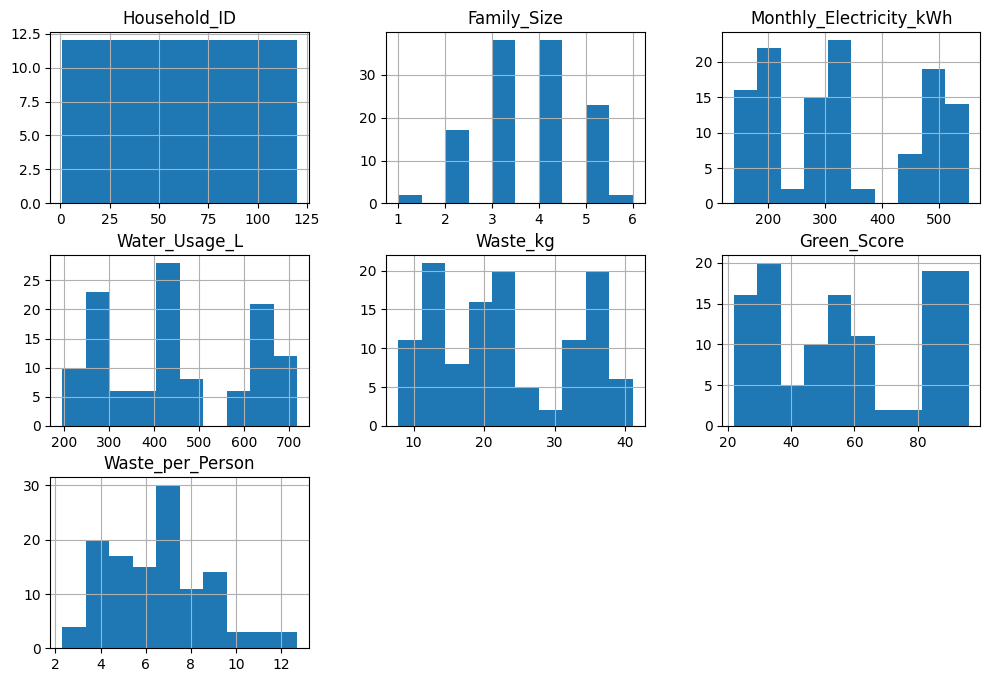

In [11]:
# histogram
df.hist(figsize=(12,8))
plt.show()

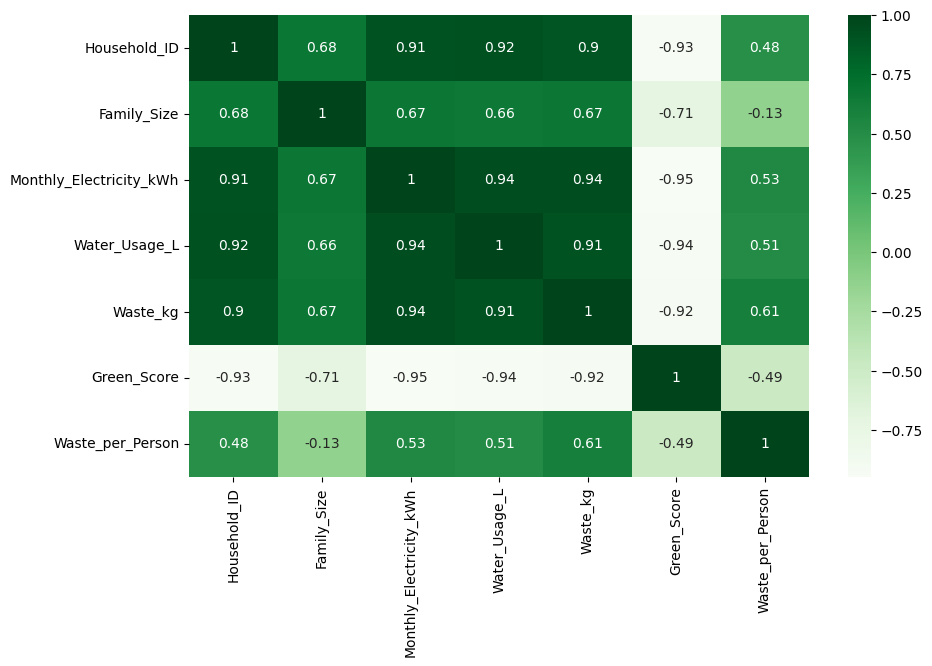

In [12]:
# corelational heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Greens'
)

plt.show()

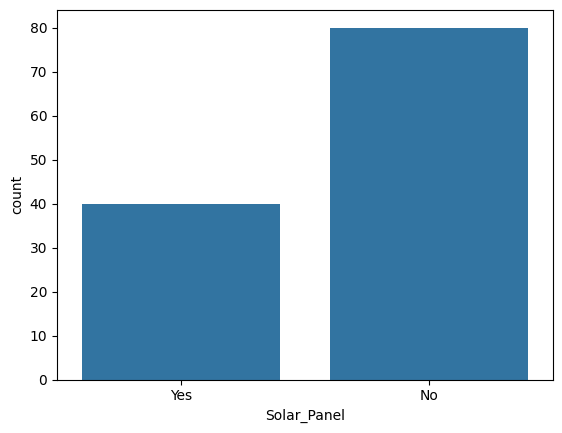

In [14]:
# count plot
sns.countplot(
    data=df,
    x='Solar_Panel'
)

plt.show()

## Encoding Categorical Features

Machine learning algorithms cannot directly process text data.

Therefore, categorical variables are converted into numerical form.

In [15]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)
df_encoded.head()

,Household_ID,Family_Size,Monthly_Electricity_kWh,Water_Usage_L,Waste_kg,Green_Score,Waste_per_Person,Solar_Panel_Yes,Compost_Yes,Vehicle_Type_EV,Vehicle_Type_Petrol
0,1,2,175.0,256.0,13.8,87,6.90,True,True,True,False
1,2,1,188.0,250.0,11.5,88,11.50,True,True,True,False
2,3,3,209.0,282.0,12.3,84,4.10,True,True,True,False
3,4,2,186.0,305.0,12.1,87,6.05,True,True,True,False
4,5,3,143.0,249.0,13.2,92,4.40,True,True,True,False


# Feature Scaling

K-Means relies on Euclidean distance.

StandardScaler standardizes features so each variable contributes equally.

In [16]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

In [17]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_encoded.columns
)

scaled_df.head()

,Household_ID,Family_Size,Monthly_Electricity_kWh,Water_Usage_L,Waste_kg,Green_Score,Waste_per_Person,Solar_Panel_Yes,Compost_Yes,Vehicle_Type_EV,Vehicle_Type_Petrol
0,-1.717677,-1.494223,-1.196952,-1.208260,-0.984264,1.201163,0.159365,1.414214,1.441153,1.246271,-0.654654
1,-1.688808,-2.442936,-1.097857,-1.245842,-1.226231,1.242955,2.314867,1.414214,1.441153,1.246271,-0.654654
2,-1.659940,-0.545510,-0.937780,-1.045405,-1.142069,1.075788,-1.152679,1.414214,1.441153,1.246271,-0.654654
3,-1.631071,-1.494223,-1.113102,-0.901340,-1.163109,1.201163,-0.238934,1.414214,1.441153,1.246271,-0.654654
4,-1.602203,-0.545510,-1.440877,-1.252105,-1.047386,1.410122,-1.012103,1.414214,1.441153,1.246271,-0.654654


# Train-Test Split

In [18]:
X_train, X_test = train_test_split(
    scaled_df,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(96, 11)
(24, 11)


# Elbow Method

The Elbow Method helps determine the optimal number of clusters.

In [19]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_train)

    wcss.append(km.inertia_)

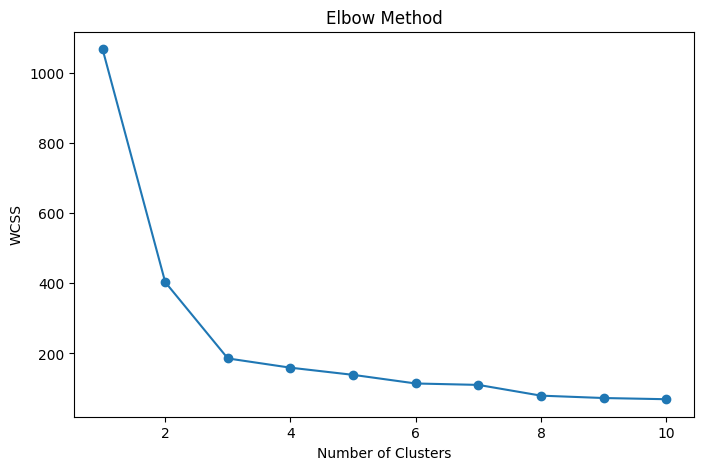

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# Applying K-Means Clustering

In [21]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_train)

KMeans(n_clusters=3, random_state=42)

In [22]:
train_clusters = kmeans.predict(X_train)
test_clusters = kmeans.predict(X_test)

# Cluster Visualization
Visualize clusters using Electricity Consumption vs Green Score

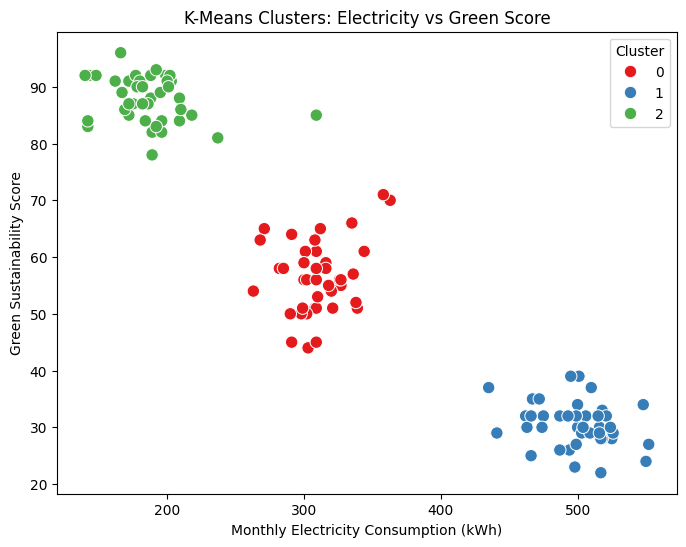

In [26]:
df_encoded["Cluster"] = kmeans.fit_predict(scaled_df)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Monthly_Electricity_kWh",
    y="Green_Score",
    hue="Cluster",
    palette="Set1",
    data=df_encoded,
    s=80
)

plt.title("K-Means Clusters: Electricity vs Green Score")
plt.xlabel("Monthly Electricity Consumption (kWh)")
plt.ylabel("Green Sustainability Score")
plt.legend(title="Cluster")

plt.show()

# Model Evaluation

We evaluate clustering quality using Silhouette Score and Inertia.

In [25]:
sil_score = silhouette_score(
    X_train,
    train_clusters
)

print("Silhouette Score:", sil_score)
print("Inertia:", kmeans.inertia_)

Silhouette Score: 0.6040078305144165
Inertia: 185.65816919710892


# Silhouette Score Interpretation

Above 0.70:
 Excellent clustering

0.50 – 0.70:
Good clustering

0.25 – 0.50:
Moderate clustering

Below 0.25:
Weak clustering

# Final Insights

• Missing values were handled using median and mode imputation.

• Categorical variables were encoded using pd.get_dummies().

• Numerical features were scaled using StandardScaler because K-Means is distance-based.

• The Elbow Method was used to determine the optimal number of clusters.

• K-Means successfully grouped similar sustainability profiles together.

• The Silhouette Score indicates the quality of cluster separation.

• Cluster analysis can help identify different household sustainability behavior patterns.

This task fulfills the expected workflow: dataset loading, cleaning, EDA with Seaborn, feature scaling, K-Means clustering, cluster visualization, evaluation with the Elbow Method and Silhouette Score, and final observations.